<a href="https://colab.research.google.com/github/stefanogiagu/corso_AI_2026/blob/main/MetodiAI_2026_E8_pyTorch_MLP_FashionMNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Metodi AI per La Fisica 2026

## Esercitazione E8: utilizzo della libreria pytorch, allenamento end-to-end di un modello ANN shallow e di un MLP per un task di classificazione e un task di regressione usando il benchmark dataset Fashion-MNIST


V1.0 - Stefano Giagu <stefano.giagu@uniroma1.it>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
import torch
import torchvision

print(torch.__version__)
print(torchvision.__version__)

2.10.0+cu128
0.25.0+cu128


### Dataset:

il dataset FashionMNIST è costituito da immagini di icone di oggetti di vestiario corrispondenti a 70k immagini.

Ogni immagine ha dimensione $(28,28)$ pixel, con un canale di intensità (scala di grigi) a 8 bit (valori di intensità di ogni pixel $\in [0,256]$).

È disponibile in varie librerie per il ML (scikit-learn, torch, tensorflow, librerie esterne...). Prendendo il dataset già disponibile in pytorch potremmo sfruttare il vantaggio di di avere conversioni automatiche in tensori torch e normalizzazioni. Leggendo il dataset invece da un input esterno, come il repository openm, in formato di ndarray numpy, dovremo convertire noi i vettori in tensori torch e normalizzarli, ma risulterà più chiaro come usare in generale datset esterni. in questo hands-on utilizzeremo questo secondo approccio.

In [ ]:
# lettura del dataset Fashion-MNIST da openml usando la libreria sklearn
# label:
# 0 T-shirt/top
# 1 Trouser
# 2 Pullover
# 3 Dress
# 4 Coat
# 5 Sandal
# 6 Shirt
# 7 Sneaker
# 8 Bag
# 9 Ankle boot

from sklearn.datasets import fetch_openml

images, labels = fetch_openml("Fashion-MNIST", version=1, return_X_y=True, as_frame=False, parser="pandas")
labels = labels.astype(int) # converte le label in int

print(images.shape)
print(labels.shape)

(70000, 784)
(70000,)


In [ ]:
#printiamo il contenuto di un'immagine ...
images[0]

array([  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   1,   0,   0,  13,  73,   0,   0,   1,
         4,   0,   0,   0,   0,   1,   1,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   3,   0,  36, 136, 127,  62,
        54,   0,   0,   0,   1,   3,   4,   0,   0,   3,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   6,   0, 102, 204,
       176, 134, 144, 123,  23,   0,   0,   0,   0,  12,  10,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   

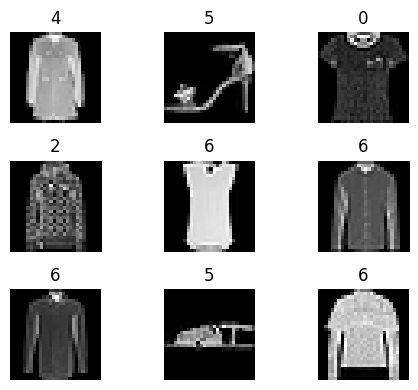

In [ ]:
# grafichiamo 9 immagini random
figure = plt.figure(figsize=(5, 4))
cols, rows = 3,3
for i in range(1, cols * rows + 1):
    sample_idx = np.random.randint(len(images))
    img, label = images[sample_idx], labels[sample_idx]
    figure.add_subplot(rows, cols, i)
    plt.title(label)
    plt.axis("off")
    plt.imshow(img.reshape((28,28)), cmap="gray")


plt.tight_layout() # inserisce un po' di spazio tra i plot
plt.show()

In [ ]:
# poiché siamo anche interessati ad implementare un MLP per un task di regressione, creiamo un traget continuo, per esempio il numero di pixel sopra una certa soglia nelle immagini

Imax = 200
npixels = np.sum(images > Imax, axis=(1))
print(npixels.shape)

(70000,)


In [ ]:
# splitting del campione in training, validation e test (60:20:20)

from sklearn.model_selection import train_test_split

X_train, X, Y_train, Y, Z_train, Z = train_test_split(images, labels, npixels, test_size=0.4, shuffle=True, random_state=12345)
X_vali, X_test, Y_vali, Y_test, Z_vali, Z_test = train_test_split(X, Y, Z, test_size=0.5, shuffle=True, random_state=456789)

print(X_train.shape)
print(Y_train.shape)
print(Z_train.shape)
print(X_vali.shape)
print(Y_vali.shape)
print(Z_vali.shape)
print(X_test.shape)
print(Y_test.shape)
print(Z_test.shape)

(42000, 784)
(42000,)
(42000,)
(14000, 784)
(14000,)
(14000,)
(14000, 784)
(14000,)
(14000,)


In [ ]:
# le immagini Fashion-MNIST sono immagini in scala di grigio a 8 bit, ogni pixel assume valore [0,255], quindi per
# normalizzare in [0,1] basta solo dividere tutte le immagini per 255.
# Metodi alternativi sono calcolare la media e la dev. standard sulle immagini di training, e poi normalizzare in N(0,1) (può essere fatto
# con Sklearn.preprocessing.StandardScaler)

X_train_norm = X_train / 255.
X_vali_norm  = X_vali / 255.
X_test_norm  = X_test / 255.

In [ ]:
# Input e label in quetso momento sono in formato numpy, per essere utilizzate in pytorch devono essere convertite in tensori torch.

X_train_pt = torch.Tensor(X_train_norm).float()
Y_train_pt = torch.Tensor(Y_train).int()
Z_train_pt = torch.Tensor(Z_train).float()
X_vali_pt = torch.Tensor(X_vali_norm).float()
Y_vali_pt = torch.Tensor(Y_vali).int()
Z_vali_pt = torch.Tensor(Z_vali).float()
X_test_pt = torch.Tensor(X_test_norm).float()
Y_test_pt = torch.Tensor(Y_test).int()
Z_test_pt = torch.Tensor(Z_test).float()

print(X_train_pt.shape)
print(Y_train_pt.shape)
print(Z_train_pt.shape)
print(X_vali_pt.shape)
print(Y_vali_pt.shape)
print(Z_vali_pt.shape)
print(X_test_pt.shape)
print(Y_test_pt.shape)
print(Z_test_pt.shape)

# creiamo un pytorch dataset e un pytroch dataloader (eg un python iterable che permette di iterare su i campioni dei dataset gestendo lo
# splitting dei minibatch, reshuffling etc...

from torch.utils.data import TensorDataset, DataLoader

dataset_train = TensorDataset(X_train_pt, Y_train_pt)
dataloader_train = DataLoader(dataset_train, batch_size=32, shuffle=True, drop_last=True, pin_memory=True, num_workers=2)

dataset_vali = TensorDataset(X_vali_pt, Y_vali_pt)
dataloader_vali = DataLoader(dataset_vali, batch_size=32, shuffle=True, drop_last=True, pin_memory=True, num_workers=2)

dataset_test = TensorDataset(X_test_pt, Y_test_pt)
dataloader_test = DataLoader(dataset_test, batch_size=1, shuffle=False, drop_last=False, pin_memory=True, num_workers=2)

dataset_train_regr = TensorDataset(X_train_pt, Z_train_pt)
dataloader_train_regr = DataLoader(dataset_train_regr, batch_size=32, shuffle=True, drop_last=True, pin_memory=True, num_workers=2)

dataset_vali_regr = TensorDataset(X_vali_pt, Z_vali_pt)
dataloader_vali_regr = DataLoader(dataset_vali_regr, batch_size=32, shuffle=True, drop_last=True, pin_memory=True, num_workers=2)

dataset_test_regr = TensorDataset(X_test_pt, Z_test_pt)
dataloader_test_regr = DataLoader(dataset_test_regr, batch_size=1, shuffle=False, drop_last=False, pin_memory=True, num_workers=2)

torch.Size([42000, 784])
torch.Size([42000])
torch.Size([42000])
torch.Size([14000, 784])
torch.Size([14000])
torch.Size([14000])
torch.Size([14000, 784])
torch.Size([14000])
torch.Size([14000])


In [ ]:
# in torch/pytorch dati e modelli devono essere mossi sull'unità di calcolo che si vuole utilizzare (cpu e GPU)

device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print('Using',device, 'device')

Using cuda device


In [ ]:
# Esempio di come si muovono tebnsori da cpu a gpu e vicevers

print('X_train_pt is in GPU: ', X_train_pt.is_cuda)
X_train_pt = X_train_pt.to(device)
print('X_train_pt is in GPU: ', X_train_pt.is_cuda)
X_train_pt = X_train_pt.to('cpu')
print('X_train_pt is in GPU: ', X_train_pt.is_cuda)


# alteranativamente (old torch style)
# usare .cuda() e .cpu()
print('X_train_pt is in GPU: ', X_train_pt.cpu())
print('X_train_pt is in GPU: ', X_train_pt.cuda())

X_train_pt is in GPU:  False
X_train_pt is in GPU:  True
X_train_pt is in GPU:  False
X_train_pt is in GPU:  tensor([[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        ...,
        [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000,  ..., 0.0039, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000]])
X_train_pt is in GPU:  tensor([[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        ...,
        [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000,  ..., 0.0039, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000]],
       device='cuda:0')


In [ ]:
# Esempio di iterazione su un dataloader

train_features, train_labels = next(iter(dataloader_train))

print(f"Feature batch shape: {train_features.size()}")
print(f"Labels batch shape: {train_labels.size()}")

an_event = train_features[0].squeeze()
a_label = train_labels[0]

print(f"Feature: {an_event}")
print(f"Label: {a_label}")

Feature batch shape: torch.Size([32, 784])
Labels batch shape: torch.Size([32])
Feature: tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.3294, 0.5608, 0.6510, 0.7216, 0.6275, 0.7059, 0.8471, 0.4196,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0039, 0.0039, 0.0000, 0.0000,
        0.0000, 0.7647, 1.0000, 0.8235, 0.7137, 0.9490, 0.9922, 0.9412, 0.8353,
        1.0000, 0.5608, 0.0000, 0.0000, 0.0000, 0.0078, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.5882, 0.8000, 0.8431, 0.8196, 0.8784, 0.8667, 0.7137, 0.9490, 0.8275,
        0.8471, 0.8353, 0.8431, 0.8078, 0.6471, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.6784, 0.8980, 0.8157, 0.8314, 0.8549, 0.8510, 0.8941, 0.8667, 0.7882,
        0.8824, 0.8667, 0.8471,

### Definizione dei modelli di rete neurali

In [ ]:
# un modello pytroch (nn.Model): è semplicemente una classe python che eredita dalla classa nn.Model di pytorch
# in cui si definiscono: i layer utilizzati, le funzioni di attiviazione utilizzate, eventuali ulteriori operazioni,
# e in cui si definisce il flusso forwqard dei dati, cioè la funzione y = f(x) che trasforma l'input nell'output

from torch import nn
import torch.nn.functional as F

# esempio di base: un MLP Shallow (1 solo layer nascosto) per un task di classificazione
class ShallowANN(nn.Module):
  def __init__(self, input_dim, output_dim):
    super(ShallowANN, self).__init__()

    #torch.nn.Linear(in_features, out_features)
    #Linear == layer MLP denso
    self.layer1 = nn.Linear(input_dim, 20)
    self.activ = nn.ReLU()
    self.layer2 = nn.Linear(20, output_dim) #output = 10 neuroni corrispondenti alle 10 classi del problema, oppure = 1 per una rgressione 1D

  def forward(self, x):
    out = self.layer1(x)
    out = self.activ(out)
    out = self.layer2(out) # non inseriamo un softmax in uscita perche' in pytorch e' automaticamente applicato nella loss x-entropy
    return out


# è immediato generalizzare il modello ad un MLP (con piu' layer nascosti per implementare deep learning)

class MyMLP(nn.Module):
  def __init__(self):
    super(MyMLP, self, input_dim, output_dim).__init__()

    self.layer1 = nn.Linear(input_dim, 20)
    self.layer2 = nn.Linear(20, 100)
    self.layer3 = nn.Linear(100, output_dim)
    self.activ = nn.ReLU()

  def forward(self, x):
    out = self.layer1(x)
    out = self.activ(out)
    out = self.layer2(out)
    out = self.activ(out)
    out = self.layer3(out)
    return out

In [ ]:
#%pip install torchsummary #not needed in colab

In [ ]:
# Printiamo un modello

model = ShallowANN(input_dim=28*28, output_dim=10)
print(model)

from torchsummary import summary
if torch.cuda.is_available():
  summary(model.cuda(), input_size=(1,28*28))
else:
  summary(model, input_size=(1,28*28))

ShallowANN(
  (layer1): Linear(in_features=784, out_features=20, bias=True)
  (activ): ReLU()
  (layer2): Linear(in_features=20, out_features=10, bias=True)
)
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                [-1, 1, 20]          15,700
              ReLU-2                [-1, 1, 20]               0
            Linear-3                [-1, 1, 10]             210
Total params: 15,910
Trainable params: 15,910
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.06
Estimated Total Size (MB): 0.06
----------------------------------------------------------------


In [ ]:
#install torchmetrics: collezione di metriche (accuracy etc.) facili da utilizzare
!pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 23.6 MB/s eta 0:00:00


In [ ]:
# ridefiniamo un nuovo modello (ogni volta che instanziate un modello setatte i suoi pesi in modo random iniziale) e spostiamolo sulla GPU

model = ShallowANN(input_dim=28*28, output_dim=10) #modello per classificazione immagine -> classe (0-10)
model.to(device)
print('model is on GPU: ',next(model.parameters()).is_cuda)

model is on GPU:  True


In [ ]:
# Definizione della funzione di loss

# classificazione multiclasse: nn.CrossEntropyLoss()
loss_fun = nn.CrossEntropyLoss() #multiclass classification (automaticamente inserisce un softmax sull'output della rete)

# NOTA: se si vuole fare una classificazione binaria si può anche usare nn.BCELoss(), che richiede un solo neurone di uscita dalal rete
# e di applicare una attivazione sigmoide in uscita dalla rete.

# NOTA2: se si vuole fare un task di regressione si può usare MSE, MAE. HuberLoss: nn.MSELoss(), nn.MAELoss(), nn.HuberLoss() ...

# metrics (accuracy)
import torchmetrics
from torchmetrics.classification import Accuracy

metric_fun = Accuracy(task="multiclass", num_classes=10)
metric_fun = metric_fun.to(device) #NOTE: deve essere spostata sulla devide di calcolo (torch lo fa automatcamente solo con le sue loss)

# Ottmizzatore
from torch import optim
#opt = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)
opt = optim.Adam(model.parameters(), lr=1e-3) #Adam

In [ ]:
# test implementazione su un batch per verificare che tutto funzioni
xb,yb = next(iter(dataloader_train))

xb=xb.type(torch.float).to(device) #sposta i tensori sulla device
yb=yb.type(torch.int64).to(device) #cuda non usa int ma int64

# predizione (semplicemnte chiamare il NN come una funzione)

pred = model(xb)
print('output shape: ', pred.shape)

# loss e metrica
loss = loss_fun(pred, yb)
metric_fun.reset()
metric = metric_fun(pred, yb)

print('loss: ', loss.item())
print('metric: ',  metric_fun.compute().item())

output shape:  torch.Size([32, 10])
loss:  2.3295202255249023
metric:  0.1875


In [ ]:
#training loop (in pytorch va scritto esplicitamente (a meno di non usare librerie esterne come PyTorch Lightning)
import time
import copy
epochs = 50 #numero di epoche di training

# liste python in cui salvare risultati intremedi per plotting della dinamica di addestramento (loss vs epoca training)
hist_loss = []
hist_metric = []
hist_val_loss = []
hist_val_metric = []

best_val = 1e9; best_state = None

# loop sulle epoche
for epoch in range(epochs):
    t0 = time.time()

    #training step
    model.train() #importante!
    epoch_train_loss = 0.0
    metric_fun.reset()
    counter = 0
    for xb, yb in dataloader_train: #loop su i minibatch
        counter += 1
        xb=xb.type(torch.float).to(device)
        yb=yb.type(torch.int64).to(device)
        pred = model(xb)
        loss = loss_fun(pred, yb)
        metric_fun.update(pred, yb)
        epoch_train_loss += loss.item()

        # backpropagation
        loss.backward()
        opt.step()
        opt.zero_grad()

    epoch_train_loss = epoch_train_loss/counter

    hist_loss.append(epoch_train_loss)

    epoch_train_metric = metric_fun.compute().item()
    hist_metric.append(epoch_train_metric)

    # validation step
    model.eval() #importante!
    epoch_val_loss = 0.0
    metric_fun.reset()
    counter = 0
    with torch.no_grad():
      for xb, yb in dataloader_vali:
        counter += 1
        xb=xb.type(torch.float).to(device)
        yb=yb.type(torch.int64).to(device)
        pred = model(xb)
        vloss = loss_fun(pred, yb)
        metric_fun.update(pred, yb)
        epoch_val_loss += vloss.item()

    epoch_val_loss = epoch_val_loss/counter

    hist_val_loss.append(epoch_val_loss)

    epoch_val_metric = metric_fun.compute().item()
    hist_val_metric.append(epoch_val_metric)

    # salva il modello migliore (quello con minima loss sul validation set)
    if vloss < best_val:
        best_state = copy.deepcopy(model.state_dict())
        best_val = vloss

    elapsed_time = time.time()-t0
    print("epoch: %d, time(s): %.4f, train loss: %.6f, train metric: %.6f, vali loss: %.6f, vali metric: %.6f"
          % (epoch+1, elapsed_time, epoch_train_loss, epoch_train_metric, epoch_val_loss, epoch_val_metric))


epoch: 1, time(s): 7.4134, train loss: 0.639159, train metric: 0.782346, vali loss: 0.484603, vali metric: 0.834025
epoch: 2, time(s): 5.8598, train loss: 0.459093, train metric: 0.841392, vali loss: 0.446277, vali metric: 0.846038
epoch: 3, time(s): 6.3469, train loss: 0.424197, train metric: 0.850776, vali loss: 0.424578, vali metric: 0.853690
epoch: 4, time(s): 5.8332, train loss: 0.404210, train metric: 0.857874, vali loss: 0.427192, vali metric: 0.848827
epoch: 5, time(s): 6.5222, train loss: 0.389101, train metric: 0.864020, vali loss: 0.398585, vali metric: 0.859554
epoch: 6, time(s): 6.1323, train loss: 0.377039, train metric: 0.866830, vali loss: 0.391384, vali metric: 0.860555
epoch: 7, time(s): 6.4287, train loss: 0.365540, train metric: 0.870856, vali loss: 0.391646, vali metric: 0.860912
epoch: 8, time(s): 5.8924, train loss: 0.356345, train metric: 0.873071, vali loss: 0.390174, vali metric: 0.863201
epoch: 9, time(s): 6.5361, train loss: 0.350325, train metric: 0.876048,

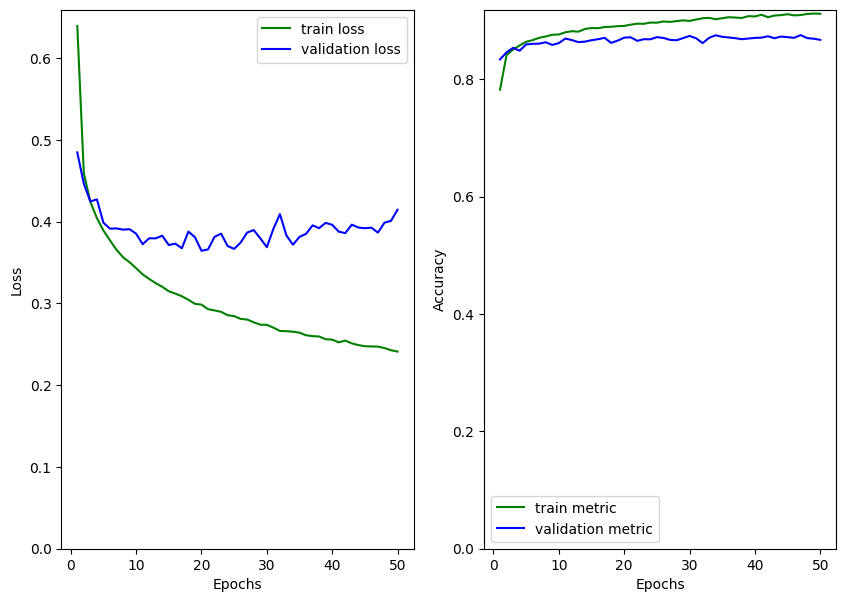

In [ ]:
# plot training results (loss and accuracy vs epoch)
plt.figure(figsize=(10, 7))
plt.subplot(1,2,1)
plt.plot(range(1,len(hist_loss)+1), hist_loss, color='green', linestyle='-', label='train loss')
plt.plot(range(1,len(hist_val_loss)+1), hist_val_loss, color='blue', linestyle='-', label='validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.ylim(ymin = 0.0)
plt.legend()
plt.subplot(1,2,2)
plt.plot(range(1,len(hist_metric)+1), hist_metric,  color='green', linestyle='-', label='train metric')
plt.plot(range(1,len(hist_val_metric)+1),hist_val_metric, color='blue', linestyle='-', label='validation metric')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.ylim(ymin = 0.0)
plt.legend()

In [ ]:
#test il modello addestrato

# prendo il modello migliore
model.load_state_dict(best_state)

# lo metto su CPU (o su GPU come preferite)
model.to(torch.device("cpu"))

X_test_pt = X_test_pt.type(torch.float).to(torch.device("cpu"))
res = model(X_test_pt)

metric_fun.reset()
metric_fun.update(res, Y_test_pt)
print('Test accuracy: ',metric_fun.compute().item())

Test accuracy:  0.8567143082618713


In [ ]:
# proviamo ad allenare un modello shallow su un task di regressione

model = ShallowANN(input_dim=28*28, output_dim=1) #modello per regressione immagine -> numero pixels sopra soglia
model.to(device)
print('model is on GPU: ',next(model.parameters()).is_cuda)

model is on GPU:  True


In [ ]:
# Definizione della funzione di loss

loss_fun = nn.MSELoss()  # MSE loss

# Ottmizzatore
from torch import optim
#opt = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)
opt = optim.Adam(model.parameters(), lr=1e-3) #Adam

In [ ]:
#training loop (in pytorch va scritto esplicitamente (a meno di non usare librerie esterne come PyTorch Lightning)
import time
import copy
epochs = 50 #numero di epoche di training

# liste python in cui salvare risultati intremedi per plotting della dinamica di addestramento (loss vs epoca training)
hist_loss = []
hist_val_loss = []

best_val = 1e9; best_state = None

# loop sulle epoche
for epoch in range(epochs):
    t0 = time.time()

    #training step
    model.train() #importante!
    epoch_train_loss = 0.0
    metric_fun.reset()
    counter = 0
    for xb, yb in dataloader_train_regr: #loop su i minibatch
        counter += 1
        xb=xb.type(torch.float).to(device)
        yb=yb.type(torch.float).to(device)
        pred = model(xb)
        loss = loss_fun(pred, torch.unsqueeze(yb,1))
        epoch_train_loss += loss.item()

        # backpropagation
        loss.backward()
        opt.step()
        opt.zero_grad()

    epoch_train_loss = epoch_train_loss/counter

    hist_loss.append(epoch_train_loss)

    # validation step
    model.eval() #importante!
    epoch_val_loss = 0.0
    metric_fun.reset()
    counter = 0
    with torch.no_grad():
      for xb, yb in dataloader_vali_regr:
        counter += 1
        xb=xb.type(torch.float).to(device)
        yb=yb.type(torch.float).to(device)
        pred = model(xb)
        vloss = loss_fun(pred, torch.unsqueeze(yb,1))
        epoch_val_loss += vloss.item()

    epoch_val_loss = epoch_val_loss/counter

    hist_val_loss.append(epoch_val_loss)


    # salva il modello migliore (quello con minima loss sul validation set)
    if vloss < best_val:
        best_state = copy.deepcopy(model.state_dict())
        best_val = vloss

    elapsed_time = time.time()-t0
    print("epoch: %d, time(s): %.4f, train loss: %.6f, vali loss: %.6f"
          % (epoch+1, elapsed_time, epoch_train_loss, epoch_val_loss))

epoch: 1, time(s): 5.9895, train loss: 8579.618252, vali loss: 6740.903834
epoch: 2, time(s): 5.6565, train loss: 6643.388387, vali loss: 6294.332028
epoch: 3, time(s): 5.3088, train loss: 6229.666329, vali loss: 5919.080162
epoch: 4, time(s): 5.7915, train loss: 5888.564146, vali loss: 5601.241537
epoch: 5, time(s): 5.2305, train loss: 5598.800350, vali loss: 5363.879850
epoch: 6, time(s): 5.8587, train loss: 5342.802437, vali loss: 5118.379801
epoch: 7, time(s): 5.4961, train loss: 5084.498687, vali loss: 4912.361259
epoch: 8, time(s): 5.9731, train loss: 4825.604906, vali loss: 4631.129343
epoch: 9, time(s): 5.2828, train loss: 4553.556289, vali loss: 4362.871113
epoch: 10, time(s): 5.7812, train loss: 4289.056389, vali loss: 4100.424951
epoch: 11, time(s): 5.4403, train loss: 4004.703720, vali loss: 3853.734033
epoch: 12, time(s): 5.3503, train loss: 3726.430442, vali loss: 3563.020271
epoch: 13, time(s): 5.7765, train loss: 3453.571232, vali loss: 3292.198450
epoch: 14, time(s): 5

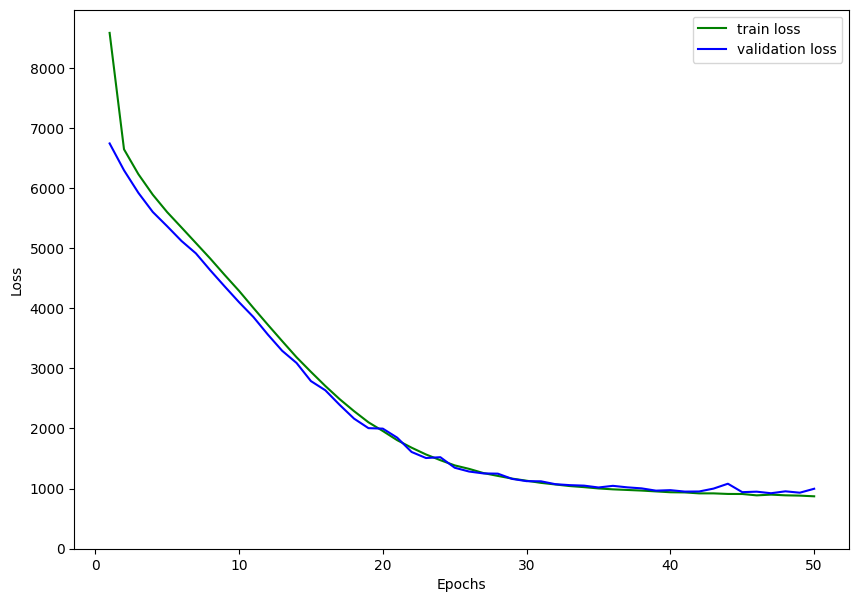

In [ ]:
# plot training results (loss and accuracy vs epoch)
plt.figure(figsize=(10, 7))
plt.plot(range(1,len(hist_loss)+1), hist_loss, color='green', linestyle='-', label='train loss')
plt.plot(range(1,len(hist_val_loss)+1), hist_val_loss, color='blue', linestyle='-', label='validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.ylim(ymin = 0.0)
plt.legend()

In [ ]:
#test il modello addestrato

# prendo il modello migliore
model.load_state_dict(best_state)

# lo metto su CPU (o su GPU come preferite)
model.to(torch.device("cpu"))

X_test_pt = X_test_pt.type(torch.float).to(torch.device("cpu"))
res = model(X_test_pt)

mae_fun = nn.L1Loss()
mae = mae_fun(res, torch.unsqueeze(Z_test_pt,1))
print('Test MAE: ',mae.item())

Test MAE:  23.289634704589844


Text(0.5, 1.0, 'Prediction VS true value')

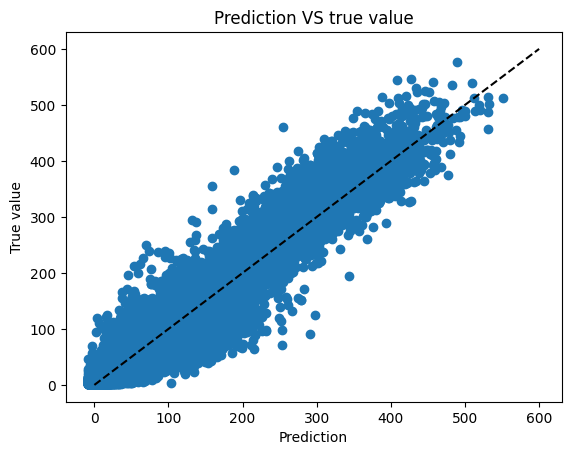

In [ ]:
# plot prediction VS true value

plt.scatter(res.detach().numpy(),Z_test_pt.numpy())
plt.plot([0, 600], [0, 600], 'k--')
plt.xlabel('Prediction')
plt.ylabel('True value')
plt.title('Prediction VS true value')


**Esercizi:**


*   giocare con parametri dei modelli, cambiare loss (ex nn.Sigmoid()), ...
*   usare il modello MLP invece che la rete shallow
*   provare a regolarizzare l'addestraento con Dropout nn.Dropout(p=prob)...

